# 🏃 Pacing Model – Vermoeidheidsvoorspelling op basis van .fit bestanden

**Doel:** Gebruik de eerste helft van een activiteit (tempo, hartslag, cadans) om het tempo in de tweede helft te voorspellen. Vergelijk de voorspelling met de werkelijkheid om vermoeidheid en de 'muur' te detecteren.

**Activiteitstype:** Hardlopen (running)

---
### Structuur
1. Installatie & imports
2. Data inladen
3. Data verkennen (EDA)
4. Data opschonen
5. Feature engineering
6. Model trainen
7. Voorspelling & evaluatie
8. Visualisaties (klaar voor Streamlit)

---
## 1. Installatie & Imports

In [6]:
# Installeer benodigde packages (eenmalig)
# !pip install fitparse pandas numpy matplotlib seaborn scikit-learn plotly

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from fitparse import FitFile
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

print('Imports geslaagd')

Imports geslaagd


---
## 2. Data Inladen

We lezen één `.fit` bestand in en zetten het om naar een Pandas DataFrame. Elk record in een `.fit` bestand is een tijdstap (meestal per seconde).

In [3]:
def load_fit_file(filepath):
    """
    Lees een .fit bestand in en retourneer een DataFrame
    met alle beschikbare velden per tijdstap (record messages).
    """
    fitfile = FitFile(filepath)
    records = []

    for record in fitfile.get_messages('record'):
        data = {}
        for field in record:
            data[field.name] = field.value
        records.append(data)

    df = pd.DataFrame(records)
    return df

In [4]:
# Pas dit pad aan naar jouw .fit bestand
FIT_FILE_PATH = 'data/StravaRobin/Midwintermarathon_Apeldoorn.fit'

df_raw = load_fit_file(FIT_FILE_PATH)

print(f'Aantal rijen (tijdstappen): {len(df_raw)}')
print(f'Beschikbare kolommen: {list(df_raw.columns)}')
df_raw.head()

Aantal rijen (tijdstappen): 11946
Beschikbare kolommen: ['activity_type', 'cadence', 'distance', 'enhanced_altitude', 'enhanced_speed', 'fractional_cadence', 'heart_rate', 'position_lat', 'position_long', 'power', 'timestamp', 'unknown_107', 'unknown_135', 'unknown_136', 'unknown_137', 'unknown_138', 'unknown_140', 'unknown_143', 'unknown_87', 'accumulated_power', 'stance_time', 'step_length', 'vertical_oscillation', 'vertical_ratio', 'unknown_90']


,activity_type,cadence,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,power,...,unknown_138,unknown_140,unknown_143,unknown_87,accumulated_power,stance_time,step_length,vertical_oscillation,vertical_ratio,unknown_90
0,running,0,0.00,40.2,0.000,0.0,78,622761274,70642344,0,...,100,0,69,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,running,0,2.52,40.2,0.000,0.0,78,622761530,70642649,0,...,100,0,69,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,running,0,5.97,40.2,0.588,0.0,79,622761826,70643012,0,...,100,582,69,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,running,0,9.85,40.2,2.295,0.0,79,622762112,70643449,0,...,100,2273,69,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,running,0,13.76,40.2,3.275,0.0,80,622762403,70643969,0,...,100,3243,69,0.0,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Data Verkennen (EDA)

Begrijp de data voordat je iets ermee doet. Welke kolommen zijn er? Zijn er missende waarden? Hoe zien de tijdreeksen eruit?

In [5]:
# Overzicht van datatypes en missende waarden
print('=== Datatypes & Missing Values ===')
missing = df_raw.isnull().sum()
dtypes = df_raw.dtypes
overview = pd.DataFrame({'dtype': dtypes, 'missing': missing, 'missing_%': (missing / len(df_raw) * 100).round(1)})
print(overview[overview['missing'] > 0])

=== Datatypes & Missing Values ===
                        dtype  missing  missing_%
unknown_87            float64       16        0.1
accumulated_power     float64        8        0.1
stance_time           float64       36        0.3
step_length           float64       21        0.2
vertical_oscillation  float64       18        0.2
vertical_ratio        float64       21        0.2
unknown_90            float64      360        3.0


In [6]:
# Beschrijvende statistieken
df_raw.describe()

,cadence,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,power,timestamp,...,unknown_138,unknown_140,unknown_143,unknown_87,accumulated_power,stance_time,step_length,vertical_oscillation,vertical_ratio,unknown_90
count,11946.000000,11946.000000,11946.000000,11946.000000,11946.000000,11946.000000,1.194600e+04,1.194600e+04,11946.000000,11946,...,11946.000000,11946.000000,11946.000000,11930.000000,1.193800e+04,11910.000000,11925.000000,11928.000000,11925.000000,11586.000000
mean,83.404905,21477.508415,69.409208,3.531607,0.324293,156.505776,6.229189e+08,7.017506e+07,416.619956,2026-01-31 11:11:00.500000256,...,48.969446,3551.731458,45.522518,4318.972003,2.546057e+06,259.064568,1267.807463,96.596504,7.630127,-2.112463
min,0.000000,0.000000,34.000000,0.000000,0.000000,78.000000,6.227218e+08,6.934723e+07,0.000000,2026-01-31 09:31:28,...,1.000000,0.000000,26.000000,0.000000,4.310000e+02,230.000000,722.000000,54.500000,3.960000,-4.000000
25%,83.000000,10821.957500,56.000000,3.406000,0.000000,153.000000,6.228186e+08,6.998623e+07,390.000000,2026-01-31 10:21:14.249999872,...,23.000000,3402.250000,34.000000,0.000000,1.289212e+06,253.000000,1226.000000,95.100000,7.420000,-4.000000
50%,84.000000,21659.955000,65.200000,3.555000,0.500000,157.000000,6.229091e+08,7.022243e+07,417.000000,2026-01-31 11:11:00.500000,...,48.000000,3582.000000,45.000000,0.000000,2.580502e+06,259.000000,1274.000000,96.900000,7.610000,-2.000000
75%,84.000000,32198.282500,83.000000,3.686000,0.500000,161.000000,6.230166e+08,7.048772e+07,440.000000,2026-01-31 12:00:46.750000128,...,74.000000,3698.000000,56.000000,0.000000,3.821210e+06,264.000000,1317.000000,98.500000,7.810000,-1.000000
max,88.000000,42219.140000,108.400000,4.292000,0.500000,172.000000,6.231454e+08,7.068531e+07,604.000000,2026-01-31 12:50:33,...,100.000000,4340.000000,69.000000,65533.000000,4.976942e+06,305.000000,1654.000000,104.700000,10.500000,3.000000
std,3.690955,12272.363122,18.854138,0.253094,0.238716,6.988372,1.149403e+05,3.557474e+05,44.077247,NaN,...,29.068410,249.200766,12.451007,14067.542316,1.447740e+06,7.580737,72.201800,3.003277,0.293796,1.612330


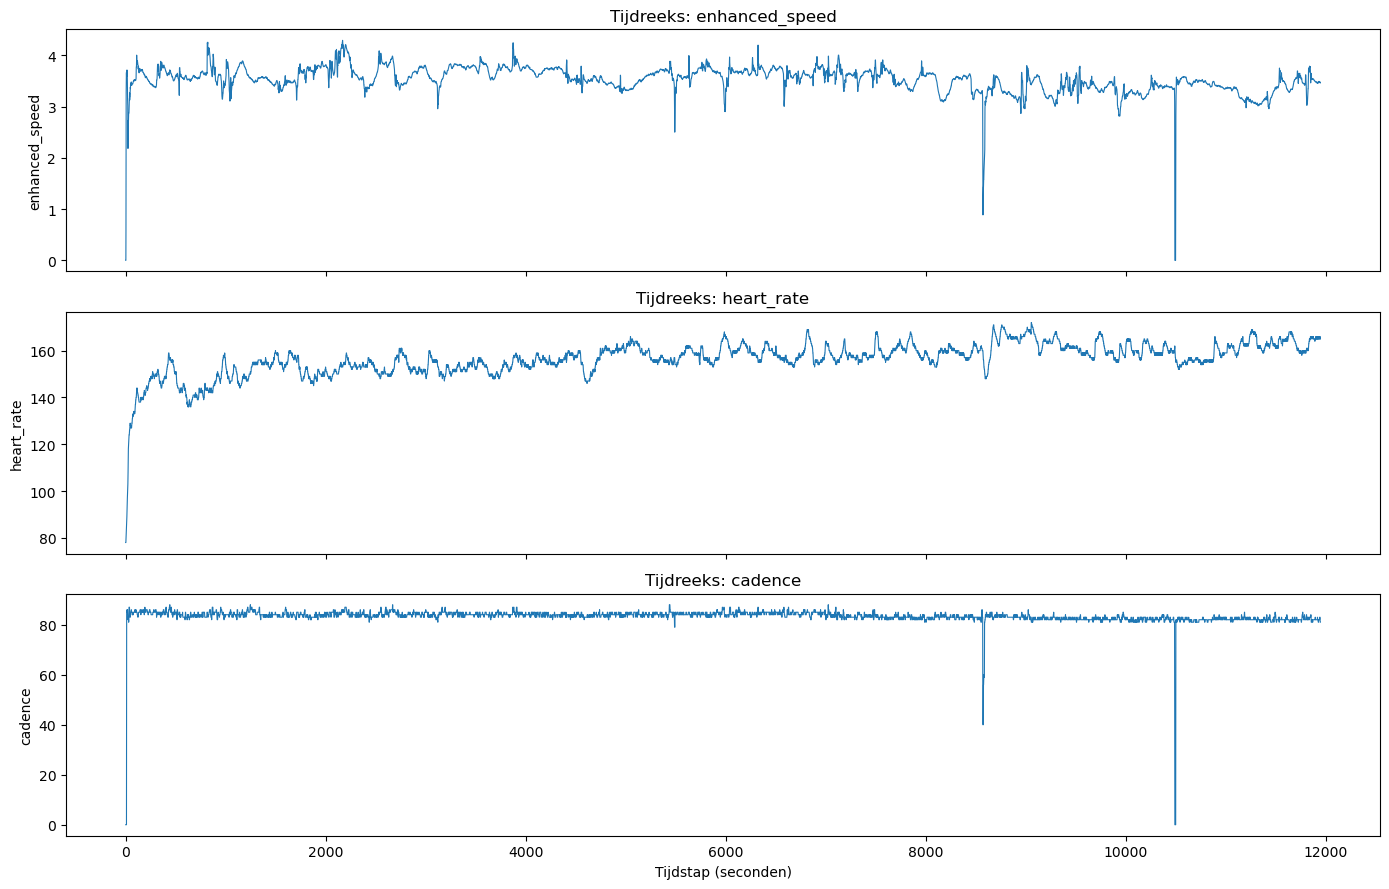

In [7]:
# Plot ruwe tijdreeksen
# Pas de kolomnamen aan als ze in jouw bestand anders heten
KOLOMMEN_OM_TE_PLOTTEN = ['enhanced_speed', 'heart_rate', 'cadence']
beschikbaar = [k for k in KOLOMMEN_OM_TE_PLOTTEN if k in df_raw.columns]

fig, axes = plt.subplots(len(beschikbaar), 1, figsize=(14, 3 * len(beschikbaar)), sharex=True)
if len(beschikbaar) == 1:
    axes = [axes]

for ax, kolom in zip(axes, beschikbaar):
    ax.plot(df_raw[kolom], linewidth=0.8)
    ax.set_ylabel(kolom)
    ax.set_title(f'Tijdreeks: {kolom}')

plt.xlabel('Tijdstap (seconden)')
plt.tight_layout()
plt.show()

---
## 4. Data Opschonen

Fit bestanden bevatten ruis: GPS-fouten, pauzes, ontbrekende waarden. We filteren dit weg.

In [8]:
def clean_fit_data(df):
    """
    Opschonen van ruwe fit data:
    - Zet timestamp als index
    - Verwijder rijen zonder snelheid of hartslag
    - Filter onrealistische waarden (stilstand, outliers)
    - Interpoleer kleine gaten
    """
    df = df.copy()

    # Timestamp als index
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp').sort_index()

    # Verwijder rijen zonder kernvariabelen
    kernvariabelen = [col for col in ['enhanced_speed', 'heart_rate', 'cadence'] if col in df.columns]
    df = df.dropna(subset=kernvariabelen)

    # Verwijder stilstand (snelheid < 0.5 m/s = ~1.8 km/h)
    if 'enhanced_speed' in df.columns:
        df = df[df['enhanced_speed'] > 0.5]

    # Filter onrealistische hartslag
    if 'heart_rate' in df.columns:
        df = df[(df['heart_rate'] > 40) & (df['heart_rate'] < 220)]

    # Interpoleer kleine gaten (max 5 seconden)
    df = df.interpolate(method='time', limit=5)

    # Reset naar numerieke index (seconden vanaf start)
    df['elapsed_seconds'] = (df.index - df.index[0]).total_seconds().astype(int)
    df = df.reset_index()

    return df

df_clean = clean_fit_data(df_raw)
print(f'Rijen voor opschonen:  {len(df_raw)}')
print(f'Rijen na opschonen:   {len(df_clean)}')
df_clean.head()

Rijen voor opschonen:  11946
Rijen na opschonen:   11936


,timestamp,activity_type,cadence,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,...,unknown_140,unknown_143,unknown_87,accumulated_power,stance_time,step_length,vertical_oscillation,vertical_ratio,unknown_90,elapsed_seconds
0,2026-01-31 09:31:30,running,0,5.97,40.2,0.588,0.0,79,622761826,70643012,...,582,69,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2026-01-31 09:31:31,running,0,9.85,40.2,2.295,0.0,79,622762112,70643449,...,2273,69,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2026-01-31 09:31:32,running,0,13.76,40.2,3.275,0.0,80,622762403,70643969,...,3243,69,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2
3,2026-01-31 09:31:33,running,0,17.33,40.2,3.639,0.0,81,622762626,70644391,...,3604,69,0.0,NaN,NaN,NaN,NaN,NaN,NaN,3
4,2026-01-31 09:31:34,running,0,21.04,40.2,3.639,0.0,83,622762870,70644956,...,3604,69,0.0,NaN,NaN,NaN,NaN,NaN,NaN,4


---
## 5. Feature Engineering

We berekenen extra features die vermoeidheid representeren:
- **Cumulatief afstand/vermogen** – hoeveel is er al geleverd?
- **Hartslag-drift** – stijgt de hartslag terwijl het tempo gelijkblijft?
- **Rolling gemiddelden** – vloeiende trends over een tijdvenster
- **Cadans-trend** – neemt de cadans af over tijd?

In [9]:
def engineer_features(df, window=60):
    """
    Bereken vermoeidheids-features op basis van de tijdreeks.
    window: grootte van het rolling venster in seconden
    """
    df = df.copy()

    # --- Cumulatieve features ---
    if 'distance' in df.columns:
        df['cumulative_distance'] = df['distance']
    elif 'enhanced_speed' in df.columns:
        df['cumulative_distance'] = df['enhanced_speed'].cumsum()

    if 'power' in df.columns:
        df['cumulative_power'] = df['power'].cumsum()

    # --- Rolling gemiddelden ---
    for col in ['enhanced_speed', 'heart_rate', 'cadence', 'power']:
        if col in df.columns:
            df[f'{col}_rolling'] = df[col].rolling(window=window, min_periods=1).mean()

    # --- Hartslag-drift ---
    # Verhouding hartslag t.o.v. snelheid: stijgt dit, dan is er drift
    if 'heart_rate' in df.columns and 'enhanced_speed' in df.columns:
        df['hr_speed_ratio'] = df['heart_rate'] / (df['enhanced_speed'] + 1e-5)
        df['hr_drift'] = df['hr_speed_ratio'].rolling(window=window, min_periods=1).mean()

    # --- Cadans-trend (afname over tijd) ---
    if 'cadence' in df.columns:
        df['cadence_trend'] = df['cadence'].rolling(window=window, min_periods=1).mean()

    # --- Relatieve positie in activiteit (0.0 – 1.0) ---
    df['progress'] = df['elapsed_seconds'] / df['elapsed_seconds'].max()

    return df

df_features = engineer_features(df_clean)
print(f'Features beschikbaar: {list(df_features.columns)}')
df_features.head()

Features beschikbaar: ['timestamp', 'activity_type', 'cadence', 'distance', 'enhanced_altitude', 'enhanced_speed', 'fractional_cadence', 'heart_rate', 'position_lat', 'position_long', 'power', 'unknown_107', 'unknown_135', 'unknown_136', 'unknown_137', 'unknown_138', 'unknown_140', 'unknown_143', 'unknown_87', 'accumulated_power', 'stance_time', 'step_length', 'vertical_oscillation', 'vertical_ratio', 'unknown_90', 'elapsed_seconds', 'cumulative_distance', 'cumulative_power', 'enhanced_speed_rolling', 'heart_rate_rolling', 'cadence_rolling', 'power_rolling', 'hr_speed_ratio', 'hr_drift', 'cadence_trend', 'progress']


,timestamp,activity_type,cadence,distance,enhanced_altitude,enhanced_speed,fractional_cadence,heart_rate,position_lat,position_long,...,cumulative_distance,cumulative_power,enhanced_speed_rolling,heart_rate_rolling,cadence_rolling,power_rolling,hr_speed_ratio,hr_drift,cadence_trend,progress
0,2026-01-31 09:31:30,running,0,5.97,40.2,0.588,0.0,79,622761826,70643012,...,5.97,0,0.588000,79.000000,0.0,0.0,134.351457,134.351457,0.0,0.000000
1,2026-01-31 09:31:31,running,0,9.85,40.2,2.295,0.0,79,622762112,70643449,...,9.85,0,1.441500,79.000000,0.0,0.0,34.422508,84.386982,0.0,0.000084
2,2026-01-31 09:31:32,running,0,13.76,40.2,3.275,0.0,80,622762403,70643969,...,13.76,0,2.052667,79.333333,0.0,0.0,24.427406,64.400457,0.0,0.000167
3,2026-01-31 09:31:33,running,0,17.33,40.2,3.639,0.0,81,622762626,70644391,...,17.33,0,2.449250,79.750000,0.0,0.0,22.258801,53.865043,0.0,0.000251
4,2026-01-31 09:31:34,running,0,21.04,40.2,3.639,0.0,83,622762870,70644956,...,21.04,0,2.687200,80.400000,0.0,0.0,22.808401,47.653715,0.0,0.000335


---
## 6. Model Trainen

We splitsen de activiteit in twee helften op basis van tijd. De **eerste helft** is trainingsdata, de **tweede helft** is testdata. Het model voorspelt het tempo (snelheid) in de tweede helft.

In [10]:
# Definieer features en target
FEATURE_COLS = [col for col in [
    'heart_rate', 'cadence', 'heart_rate_rolling', 'cadence_rolling',
    'hr_drift', 'cadence_trend', 'hr_speed_ratio',
    'cumulative_distance', 'cumulative_power',
    'elapsed_seconds', 'progress'
] if col in df_features.columns]

TARGET_COL = 'enhanced_speed'

print(f'Gebruikte features: {FEATURE_COLS}')
print(f'Target: {TARGET_COL}')

Gebruikte features: ['heart_rate', 'cadence', 'heart_rate_rolling', 'cadence_rolling', 'hr_drift', 'cadence_trend', 'hr_speed_ratio', 'cumulative_distance', 'cumulative_power', 'elapsed_seconds', 'progress']
Target: enhanced_speed


In [11]:
# Splits in eerste en tweede helft op basis van tijd
midpoint = df_features['elapsed_seconds'].max() / 2

df_first_half  = df_features[df_features['elapsed_seconds'] <= midpoint].copy()
df_second_half = df_features[df_features['elapsed_seconds'] >  midpoint].copy()

X_train = df_first_half[FEATURE_COLS].fillna(0)
y_train = df_first_half[TARGET_COL]

X_test  = df_second_half[FEATURE_COLS].fillna(0)
y_test  = df_second_half[TARGET_COL]

print(f'Trainingsset: {len(X_train)} tijdstappen (eerste helft)')
print(f'Testset:      {len(X_test)} tijdstappen (tweede helft)')

Trainingsset: 5972 tijdstappen (eerste helft)
Testset:      5964 tijdstappen (tweede helft)


In [12]:
# Train meerdere modellen en vergelijk
modellen = {
    'Lineaire Regressie': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42)
}

resultaten = {}
for naam, model in modellen.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultaten[naam] = {
        'model':  model,
        'y_pred': y_pred,
        'MAE':    mean_absolute_error(y_test, y_pred),
        'RMSE':   np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2':     r2_score(y_test, y_pred)
    }
    print(f'{naam:25s} → MAE: {resultaten[naam]["MAE"]:.4f} | RMSE: {resultaten[naam]["RMSE"]:.4f} | R²: {resultaten[naam]["R2"]:.4f}')

Lineaire Regressie        → MAE: 0.2189 | RMSE: 0.3184 | R²: -0.8336
Random Forest             → MAE: 0.0635 | RMSE: 0.1173 | R²: 0.7514
Gradient Boosting         → MAE: 0.0415 | RMSE: 0.0872 | R²: 0.8624


In [13]:
# Kies het beste model op basis van laagste MAE
beste_naam = min(resultaten, key=lambda x: resultaten[x]['MAE'])
beste_model = resultaten[beste_naam]['model']
y_pred_best = resultaten[beste_naam]['y_pred']

print(f'Beste model: {beste_naam}')

Beste model: Gradient Boosting


---
## 7. Voorspelling & Evaluatie

Vergelijk de voorspelde snelheid met de werkelijke snelheid in de tweede helft. Detecteer waar de atleet significant vertraagt ('de muur').

In [14]:
# Bouw resultaat-DataFrame voor tweede helft
df_result = df_second_half[['elapsed_seconds', 'enhanced_speed', 'heart_rate', 'cadence']].copy()
df_result['speed_predicted'] = y_pred_best
df_result['afwijking']       = df_result['enhanced_speed'] - df_result['speed_predicted']
df_result['afwijking_pct']   = (df_result['afwijking'] / df_result['speed_predicted']) * 100

df_result.head(10)

,elapsed_seconds,enhanced_speed,heart_rate,cadence,speed_predicted,afwijking,afwijking_pct
5972,5972,3.471,165,86,3.463159,0.007841,0.226407
5973,5973,3.452,165,86,3.448126,0.003874,0.112339
5974,5974,3.434,166,86,3.407690,0.026310,0.772073
5975,5975,3.424,166,86,3.348042,0.075958,2.268723
5976,5976,3.415,166,86,3.343560,0.071440,2.136637
5977,5977,3.396,166,86,3.338444,0.057556,1.724037
5978,5978,3.331,167,86,3.189043,0.141957,4.451388
5979,5979,3.275,167,87,3.194027,0.080973,2.535128
5980,5980,3.266,167,87,3.157556,0.108444,3.434423
5981,5981,3.126,167,87,3.063922,0.062078,2.026107


In [15]:
# Detecteer de 'muur': punt van grootste negatieve afwijking
DREMPEL_PCT = -10  # Meer dan 10% langzamer dan voorspeld

muur_kandidaten = df_result[df_result['afwijking_pct'] < DREMPEL_PCT]

if not muur_kandidaten.empty:
    muur_tijdstap = muur_kandidaten.iloc[0]['elapsed_seconds']
    muur_minuut   = int(muur_tijdstap // 60)
    print(f'Muur gedetecteerd rond minuut {muur_minuut} ({int(muur_tijdstap)}s)')
else:
    muur_tijdstap = None
    print('Geen duidelijke muur gedetecteerd – consistent pacing!')

Muur gedetecteerd rond minuut 142 (8568s)


In [17]:
# Hoofdplot: voorspelling vs werkelijkheid
fig = go.Figure()

# Eerste helft (werkelijk)
fig.add_trace(go.Scatter(
    x=df_first_half['elapsed_seconds'] / 60,
    y=df_first_half['enhanced_speed'],
    name='Werkelijk (1e helft)',
    line=dict(color='steelblue', width=1.5)
))

# Tweede helft werkelijk
fig.add_trace(go.Scatter(
    x=df_result['elapsed_seconds'] / 60,
    y=df_result['enhanced_speed'],
    name='Werkelijk (2e helft)',
    line=dict(color='orange', width=1.5)
))

# Voorspelling tweede helft
fig.add_trace(go.Scatter(
    x=df_result['elapsed_seconds'] / 60,
    y=df_result['speed_predicted'],
    name='Voorspeld (2e helft)',
    line=dict(color='green', width=2, dash='dash')
))

# Verticale lijn: halverwege
fig.add_vline(x=midpoint / 60, line_dash='dot', line_color='gray', annotation_text='Halverwege')

# Muur marker
if muur_tijdstap:
    fig.add_vline(x=muur_tijdstap / 60, line_dash='solid', line_color='red', annotation_text='Muur')

fig.update_layout(
    title='Pacing Model – Voorspelling vs Werkelijkheid',
    xaxis_title='Tijd (minuten)',
    yaxis_title='Snelheid (m/s)',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    height=450
)
fig.show()

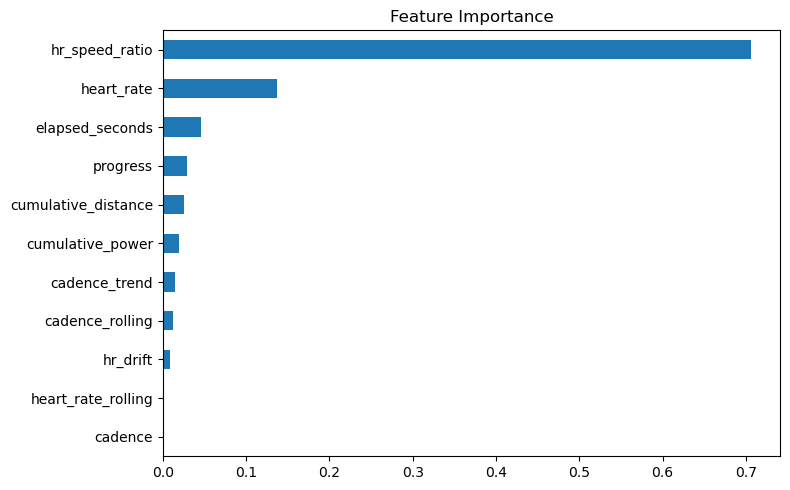

In [18]:
# Feature importance (alleen voor boomgebaseerde modellen)
if hasattr(beste_model, 'feature_importances_'):
    importances = pd.Series(beste_model.feature_importances_, index=FEATURE_COLS)
    importances.sort_values().plot(kind='barh', figsize=(8, 5), title='Feature Importance')
    plt.tight_layout()
    plt.show()

---
## 8. Exporteer voor Streamlit

Sla de verwerkte data en het model op zodat het Streamlit dashboard ze direct kan inladen.

In [ ]:
# import pickle

# # Sla verwerkte data op
# df_features.to_csv('data/activiteit_features.csv', index=False)
# df_result.to_csv('data/activiteit_resultaten.csv', index=False)

# # Sla model op
# with open('data/pacing_model.pkl', 'wb') as f:
#     pickle.dump(beste_model, f)

# # Sla model metrics op
# metrics = {
#     'model_naam':   beste_naam,
#     'MAE':          resultaten[beste_naam]['MAE'],
#     'RMSE':         resultaten[beste_naam]['RMSE'],
#     'R2':           resultaten[beste_naam]['R2'],
#     'muur_seconde': muur_tijdstap,
#     'feature_cols': FEATURE_COLS
# }

# import json
# with open('data/model_metrics.json', 'w') as f:
#     json.dump(metrics, f, indent=2)

# print('Data, model en metrics opgeslagen in /data/')